<div style="font-family:verdana;"><span style="font-size:400%;"> <center>Module 3: Bootstrap Methods</center> </span>
    
</div>





# <p style="background-color:darkred;color:white;font-family:verdana;font-size:120%;text-align:center;border-radius: 15px 50px;">Contents</p>

**<a href=#1.-Introduction>1. Introduction</a>**

**<a href=#2.-The-logic-of-the-bootstrap>2. The logic of the bootstrap</a>**

**<a href=#3.-Comparing-bootstrap-confidence-intervals>3. Comparing bootstrap confidence intervals</a>**

**<a href=#4.-Strengths-and-limitations-of-the-bootstrap>4. Strengths and limitations of the bootstrap</a>**

**<a href=#5.-Takeaways>5. Takeaways</a>**


# <p style="background-color:darkred;color:white;font-family:verdana;font-size:120%;text-align:center;border-radius: 15px 50px;">1. Introduction</p>

This notebook introduces the bootstrap as a nonparametric method for approximating sampling distributions and constructing confidence intervals.

The main goals are:

1. understand the logic of bootstrap resampling,
2. build bootstrap distributions for common statistics,
3. compare different bootstrap confidence intervals,
4. see why bootstrap methods are especially useful under skewness or for robust statistics such as the median.

## 📙 Import libraries and modules

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from nonparametric_stats.bootstrap import (
    bootstrap_distribution,
    bootstrap_ci_percentile,
    bootstrap_ci_normal,
    bootstrap_ci_basic,
)

## ⚙️ Configuration

In [2]:
rng = np.random.default_rng(42)

# <p style="background-color:darkred;color:white;font-family:verdana;font-size:120%;text-align:center;border-radius: 15px 50px;">2. The logic of the bootstrap</p>

The bootstrap treats the empirical distribution of the observed sample as a stand-in for the unknown population.

The idea is simple:

1. sample with replacement from the observed data,
2. recompute the statistic of interest,
3. repeat many times,
4. use the resulting bootstrap distribution to approximate sampling variability.

This is one of the most important ideas in modern statistics because it allows uncertainty quantification without relying entirely on closed-form parametric theory.

In [3]:
x = rng.lognormal(mean=0.0, sigma=1.0, size=100)

sample_summary = pd.DataFrame({
    "quantity": ["n", "sample mean", "sample median", "sample std"],
    "value": [len(x), np.mean(x), np.median(x), np.std(x, ddof=1)],
})

sample_summary.round(4)

,quantity,value
0,n,100.0000
1,sample mean,1.2672
2,sample median,0.9980
3,sample std,1.0962


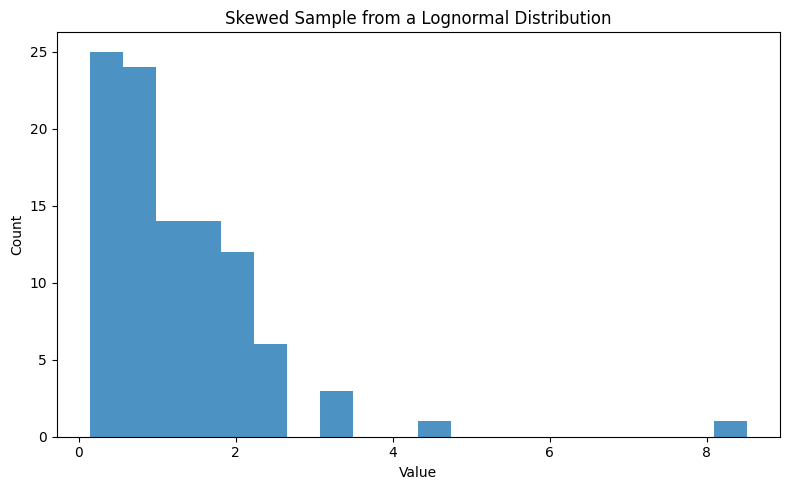

In [4]:
plt.figure(figsize=(8, 5))
plt.hist(x, bins=20, alpha=0.8)
plt.xlabel("Value")
plt.ylabel("Count")
plt.title("Skewed Sample from a Lognormal Distribution")
plt.tight_layout()
plt.savefig("../reports/figures/bootstrap_lognormal_sample.png", dpi=150, bbox_inches="tight")
plt.show()

The sample is clearly right-skewed. This makes it a useful setting for bootstrap methods, since normal-theory approximations can become less reliable, especially for statistics like the median.

In [5]:
boot_median = bootstrap_distribution(
    stat_func=np.median,
    x=x,
    n_resamples=5000,
    random_state=42,
)

median_summary = pd.DataFrame({
    "quantity": ["Sample median", "Bootstrap mean of medians", "Bootstrap SE of median"],
    "value": [np.median(x), np.mean(boot_median), np.std(boot_median, ddof=1)],
})

median_summary.round(4)

,quantity,value
0,Sample median,0.9980
1,Bootstrap mean of medians,1.0081
2,Bootstrap SE of median,0.1331


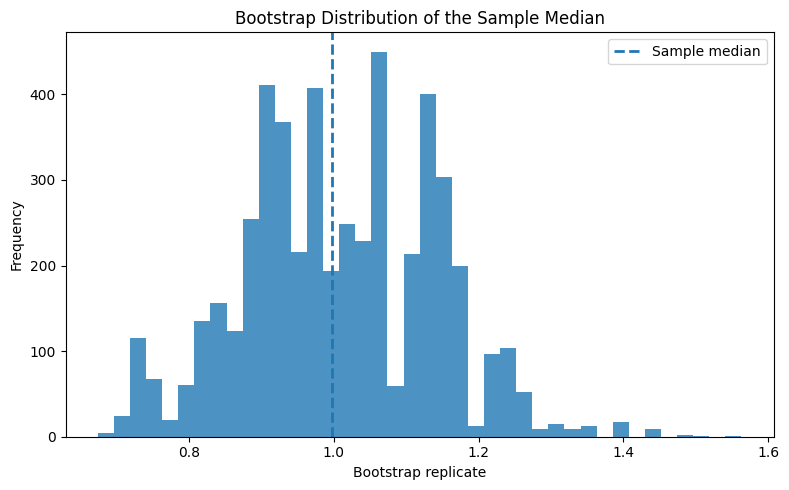

In [6]:
plt.figure(figsize=(8, 5))
plt.hist(boot_median, bins=40, alpha=0.8)
plt.axvline(np.median(x), linestyle="--", linewidth=2, label="Sample median")
plt.xlabel("Bootstrap replicate")
plt.ylabel("Frequency")
plt.title("Bootstrap Distribution of the Sample Median")
plt.legend()
plt.tight_layout()
plt.savefig("../reports/figures/bootstrap_median_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

The histogram above approximates the sampling distribution of the sample median by resampling from the empirical distribution.

This is the core bootstrap idea: repeated resampling from the observed sample can stand in for repeated sampling from the unknown population.

In [7]:
ci_percentile = bootstrap_ci_percentile(np.median, x, n_resamples=5000, random_state=42)
ci_normal = bootstrap_ci_normal(np.median, x, n_resamples=5000, random_state=42)
ci_basic = bootstrap_ci_basic(np.median, x, n_resamples=5000, random_state=42)

ci_summary = pd.DataFrame({
    "method": ["Percentile", "Normal approximation", "Basic bootstrap"],
    "lower": [ci_percentile[0], ci_normal[0], ci_basic[0]],
    "upper": [ci_percentile[1], ci_normal[1], ci_basic[1]],
})

ci_summary.round(4)

,method,lower,upper
0,Percentile,0.7339,1.2529
1,Normal approximation,0.7371,1.2588
2,Basic bootstrap,0.7430,1.2620


# <p style="background-color:darkred;color:white;font-family:verdana;font-size:120%;text-align:center;border-radius: 15px 50px;">3. Comparing bootstrap confidence intervals</p>

Different bootstrap intervals use the bootstrap distribution in different ways.

- The **percentile interval** uses empirical quantiles of the bootstrap replicates.
- The **normal approximation interval** uses the bootstrap standard error and imposes a normal approximation around the original estimate.
- The **basic bootstrap interval** reflects the percentile logic around the original estimator.

These intervals often differ, especially in skewed settings.

In [8]:
boot_mean = bootstrap_distribution(
    stat_func=np.mean,
    x=x,
    n_resamples=5000,
    random_state=42,
)

comparison_summary = pd.DataFrame({
    "statistic": ["Mean", "Median"],
    "original_estimate": [np.mean(x), np.median(x)],
    "bootstrap_se": [np.std(boot_mean, ddof=1), np.std(boot_median, ddof=1)],
})

comparison_summary.round(4)

,statistic,original_estimate,bootstrap_se
0,Mean,1.2672,0.1085
1,Median,0.9980,0.1331


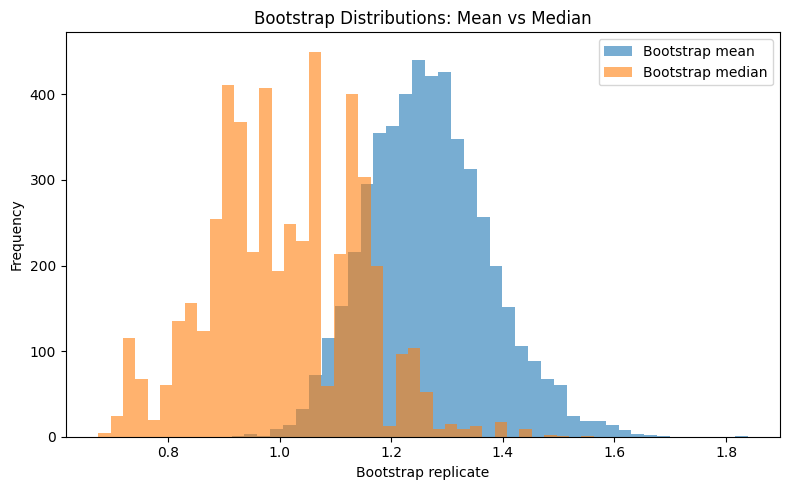

In [9]:
plt.figure(figsize=(8, 5))
plt.hist(boot_mean, bins=40, alpha=0.6, label="Bootstrap mean")
plt.hist(boot_median, bins=40, alpha=0.6, label="Bootstrap median")
plt.xlabel("Bootstrap replicate")
plt.ylabel("Frequency")
plt.title("Bootstrap Distributions: Mean vs Median")
plt.legend()
plt.tight_layout()
plt.savefig("../reports/figures/bootstrap_mean_vs_median.png", dpi=150, bbox_inches="tight")
plt.show()

The bootstrap distributions for the mean and median need not have the same shape or spread. In skewed data, the mean is often more influenced by the long tail, while the median behaves more robustly.

This comparison highlights one of the main practical uses of the bootstrap: it helps us understand the sampling behavior of statistics that do not share the same classical normal-theory convenience.

# <p style="background-color:darkred;color:white;font-family:verdana;font-size:120%;text-align:center;border-radius: 15px 50px;">4. Strengths and limitations of the bootstrap</p>

**Strengths**
- broadly applicable,
- easy to implement,
- useful for complicated or robust statistics,
- often avoids difficult analytic derivations.

**Limitations**
- not exact,
- can perform poorly in very small samples,
- may struggle for highly unstable statistics,
- still depends on the observed sample being informative about the population.

The bootstrap is therefore best understood as a powerful approximation tool, not a universal cure-all.

In [10]:
final_summary = pd.DataFrame({
    "concept": [
        "Empirical distribution as proxy",
        "Bootstrap distribution",
        "Bootstrap confidence interval",
        "Mean vs median comparison",
    ],
    "meaning": [
        "Observed sample stands in for the unknown population",
        "Approximates sampling variability by resampling with replacement",
        "Uses bootstrap replicates to quantify uncertainty",
        "Shows how different statistics respond differently under skewness",
    ],
})

final_summary

,concept,meaning
0,Empirical distribution as proxy,Observed sample stands in for the unknown popu...
1,Bootstrap distribution,Approximates sampling variability by resamplin...
2,Bootstrap confidence interval,Uses bootstrap replicates to quantify uncertainty
3,Mean vs median comparison,Shows how different statistics respond differe...


# <p style="background-color:darkred;color:white;font-family:verdana;font-size:120%;text-align:center;border-radius: 15px 50px;">5. Takeaways</p>

This notebook introduced bootstrap methods as a flexible nonparametric approach to uncertainty quantification.

- The bootstrap approximates sampling distributions by resampling with replacement from the observed data.
- It is especially useful for statistics such as the median, where classical theory may be less convenient.
- Different bootstrap confidence intervals can give different answers, especially in skewed settings.
- The bootstrap is powerful because it converts uncertainty quantification into a computational procedure.

The deeper lesson is that modern statistics often replaces analytic difficulty with principled computation.